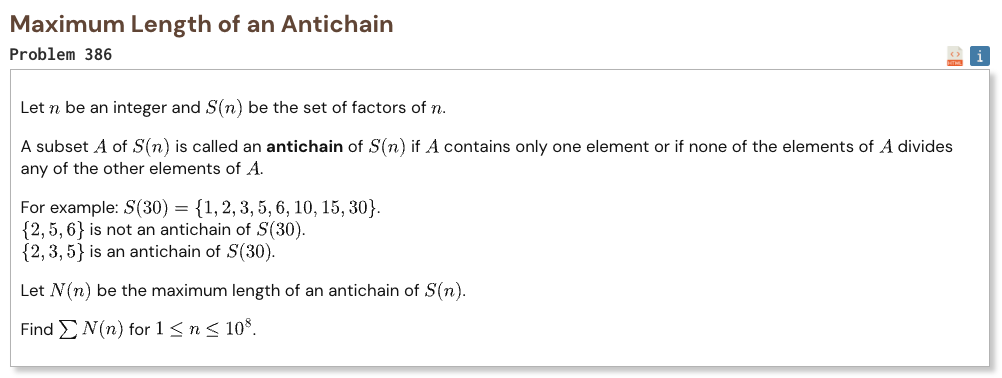

## Initial approach

* the largest antichain size is the largest coefficient of the polynomial built from the prime exponents
* factor numbers in blocks so we do not store information for all numbers up to 10^8 at once
* update the polynomial coefficients whenever a prime factor is found
* use numpy for compact block arrays and numba to compile the heavy nested loops
* add the largest coefficient for every number to get the final sum

In [1]:
import math

import numpy as np
from numba import njit


def generate_primes(limit):
    is_prime = np.ones(limit + 1, dtype=np.bool_)
    is_prime[:2] = False

    for value in range(2, math.isqrt(limit) + 1):
        if is_prime[value]:
            is_prime[value * value : limit + 1 : value] = False

    return np.flatnonzero(is_prime).astype(np.int64)


@njit
def process_block(low, high, primes, max_degree):
    size = high - low
    remaining = np.empty(size, dtype=np.int64)
    degrees = np.zeros(size, dtype=np.uint8)
    coefficients = np.zeros((size, max_degree + 1), dtype=np.uint32)

    for index in range(size):
        remaining[index] = low + index
        coefficients[index, 0] = 1

    for prime in primes:
        if prime * prime >= high:
            break

        first = ((low + prime - 1) // prime) * prime

        for value in range(first, high, prime):
            index = value - low
            exponent = 0

            while remaining[index] % prime == 0:
                remaining[index] //= prime
                exponent += 1

            if exponent == 0:
                continue

            degree = degrees[index]

            for position in range(degree + exponent, -1, -1):
                total = 0
                minimum = max(0, position - degree)
                maximum = min(exponent, position)

                for used in range(minimum, maximum + 1):
                    total += coefficients[index, position - used]

                coefficients[index, position] = total

            degrees[index] = degree + exponent

    block_total = 0

    for index in range(size):
        degree = degrees[index]

        if remaining[index] > 1:
            for position in range(degree + 1, 0, -1):
                coefficients[index, position] += coefficients[index, position - 1]

            degree += 1

        largest = 0

        for position in range(degree + 1):
            value = coefficients[index, position]

            if value > largest:
                largest = value

        block_total += largest

    return block_total


def solve(limit, block_size=500_000):
    primes = generate_primes(math.isqrt(limit) + 1)
    max_degree = limit.bit_length() - 1
    result = 0

    for low in range(1, limit + 1, block_size):
        high = min(low + block_size, limit + 1)
        result += process_block(low, high, primes, max_degree)

    return result

In [2]:
%%time
result = solve(10**8)
print("Result:", result)

Result: 528755790
CPU times: user 13.4 s, sys: 955 ms, total: 14.3 s
Wall time: 12.7 s
